In [5]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer

device = "cuda" if torch.cuda.is_available() else "cpu"

print("Loading Mistral 7B...")
mistral = AutoModelForCausalLM.from_pretrained("mistralai/Mistral-7B-v0.1", device_map="auto", attn_implementation="eager")
mistral_tokenizer = AutoTokenizer.from_pretrained("mistralai/Mistral-7B-v0.1")
mistral_tokenizer.pad_token = mistral_tokenizer.eos_token


Loading Mistral 7B...


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

Some parameters are on the meta device because they were offloaded to the disk and cpu.


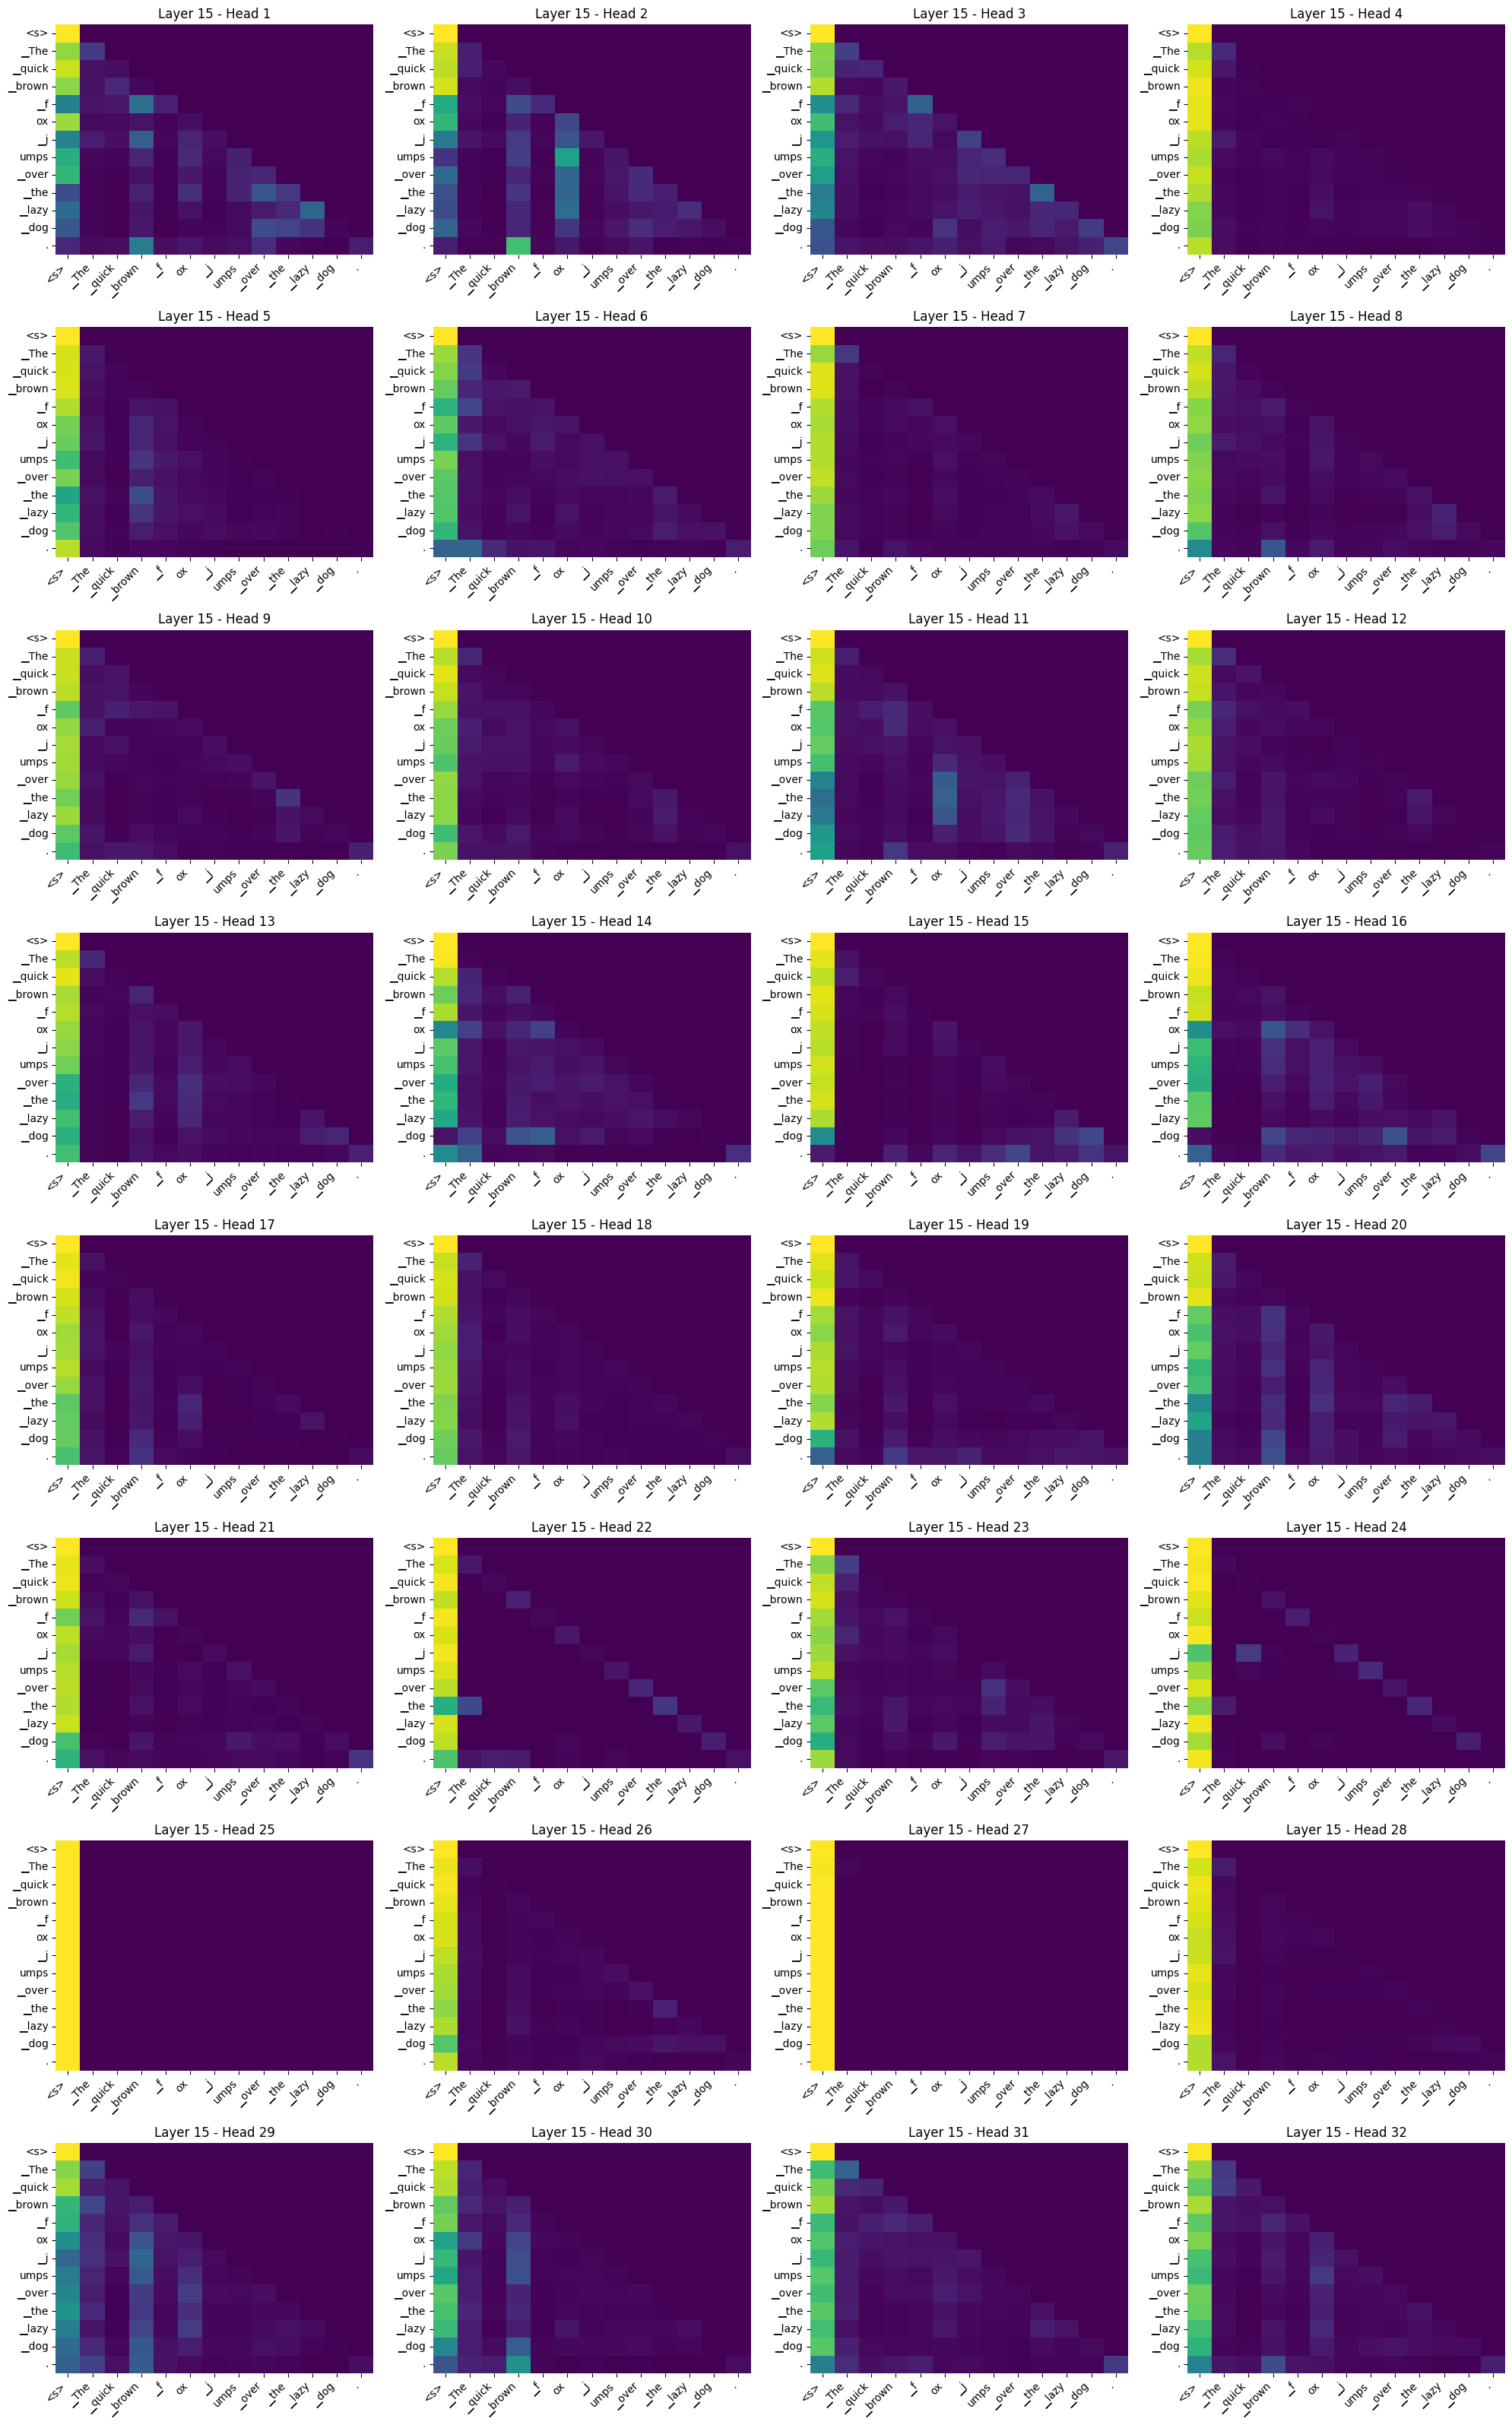

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

sample_text = "The quick brown fox jumps over the lazy dog."

# ---------------------------------------------------------
# 1. MISTRAL 7B ATTENTION EXTRACTION
# ---------------------------------------------------------
mistral_inputs = mistral_tokenizer(sample_text, return_tensors="pt").to(device)
with torch.no_grad():
    mistral_outputs = mistral(**mistral_inputs, output_attentions=True)

# Extract attention matrix from middle layer (e.g., layer 15)
# attentions shape: (batch_size, num_heads, sequence_length, sequence_length)
mistral_attn = mistral_outputs.attentions[15]
mistral_attn_maps = mistral_attn[0].cpu().to(torch.float32).numpy() # (num_heads, seq_len, seq_len)
mistral_tokens = mistral_tokenizer.convert_ids_to_tokens(mistral_inputs['input_ids'][0])

mistral_tokens_clean = [t.replace(' ', '') for t in mistral_tokens]

# ---------------------------------------------------------
# 2. VISUALIZATION
# ---------------------------------------------------------
num_heads = mistral_attn_maps.shape[0]
cols = 4
rows = math.ceil(num_heads / cols)
fig, axes = plt.subplots(rows, cols, figsize=(20, 4 * rows))
axes = axes.flatten()

for i in range(num_heads):
    sns.heatmap(mistral_attn_maps[i], xticklabels=mistral_tokens_clean, yticklabels=mistral_tokens_clean, cmap='viridis', ax=axes[i], cbar=False)
    axes[i].set_title(f"Layer 15 - Head {i+1}")
    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=45, ha='right')
    axes[i].set_yticklabels(axes[i].get_yticklabels(), rotation=0)

for i in range(num_heads, len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()
